# Evaluating Probabilistic Prediction Performance of Natural Gradient Boosting for Water Quality Classification

**Replikasi BAB 3 (Metodologi) & BAB 4 (Hasil dan Pembahasan)**

Notebook ini menjalankan keseluruhan pipeline eksperimen dari paper:
prediksi kelayakan air minum (*water potability*) menggunakan **NGBoost** (Natural
Gradient Boosting) sebagai model probabilistik, dengan baseline **XGBoost** dan
**Random Forest**.

Notebook dirancang untuk dijalankan **langsung di Google Colab** (menu *Runtime →
Run all*). Seluruh angka, tabel, dan gambar dihasilkan secara otomatis dan
konsisten dengan hasil yang dilaporkan pada paper.

---
### Ringkasan alur
| Tahap | Bagian | Isi |
|---|---|---|
| Persiapan | Sel 1-3 | Instalasi dependensi, impor, konfigurasi |
| **BAB 3** | 3.1 - 3.4 | Deskripsi dataset, imputasi MICE, split 70/15/15, scaling, evaluasi SMOTE-ENN, arsitektur model |
| **BAB 4** | 4.1 - 4.6 | Perbandingan performa, confusion matrix, uji McNemar, analisis ketidakpastian, kalibrasi, dampak SMOTE-ENN, feature importance |

> **Catatan reproduktibilitas.** Versi pustaka dikunci agar identik dengan
> lingkungan acuan (`scikit-learn==1.6.1`, `xgboost==2.1.4`, `ngboost==0.5.10`,
> `random_state=42`). NGBoost menggunakan *minibatch* dan *column subsampling*
> yang bersifat stokastik, sehingga selisih desimal kecil terhadap angka pada
> teks paper masih mungkin terjadi antar-lingkungan; angka pada notebook ini
> mengikuti pipeline acuan (`generate_figures.py`/`results.json`).

## 1. Instalasi Dependensi

Sel ini memasang pustaka dengan versi yang dikunci agar hasil reproducible di
Colab. Jika Colab meminta *restart runtime* setelah instalasi, lakukan restart
lalu jalankan ulang dari sel ini.

In [1]:
# Instalasi versi yang dikunci (sesuai lingkungan acuan paper)
!pip install -q \
    scikit-learn==1.6.1 \
    xgboost==2.1.4 \
    ngboost==0.5.10 \
    imbalanced-learn \
    seaborn \
    matplotlib \
    pandas \
    scipy
print("Instalasi selesai.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 2.33.15 requires python-dateutil<=2.9.0,>=2.1, but you have python-dateutil 2.9.0.post0 which is incompatible.


Instalasi selesai.


## 2. Impor Pustaka & Konfigurasi Global

`RANDOM_STATE = 42` dipakai konsisten di seluruh notebook (imputasi, split,
inisialisasi model) untuk menjamin hasil dapat direproduksi.

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, roc_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from imblearn.combine import SMOTEENN
from scipy.stats import chi2

warnings.filterwarnings("ignore")
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)

RANDOM_STATE = 42
COLORS = {"NGBoost": "#2196F3", "XGBoost": "#4CAF50", "Random Forest": "#FF9800"}

import sklearn, xgboost, ngboost as _ngb, imblearn
print("scikit-learn :", sklearn.__version__)
print("xgboost      :", xgboost.__version__)
print("ngboost      :", _ngb.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn : 1.6.1
xgboost      : 2.1.4
ngboost      : 0.5.10
imbalanced-learn: 0.14.2


## BAB 3 - METODOLOGI

### 3.1 Deskripsi Dataset

Dataset *Water Potability* terdiri atas **3.276 sampel** air dengan **9 fitur
fisikokimia**: pH, Hardness, Solids (Total Dissolved Solids), Chloramines,
Sulfate, Conductivity, Organic Carbon, Trihalomethanes, dan Turbidity. Target
biner `Potability` menyatakan layak minum (1) atau tidak (0).

**Pemuatan data (kombinasi otomatis + manual):** sel berikut mencoba (a) memakai
berkas lokal bila ada, lalu (b) mengunduh otomatis dari repositori GitHub. Jika
keduanya gagal (mis. tanpa internet), tersedia *fallback* unggah manual di Colab.

In [3]:
CSV_PATH = "water_potability.csv"
RAW_URL = (
    "https://raw.githubusercontent.com/"
    "aflahzaki/MetodPen-ICoICT-/main/water_potability.csv"
)


def muat_dataset(path: str = CSV_PATH, url: str = RAW_URL) -> pd.DataFrame:
    '''Memuat dataset: lokal -> unduh GitHub -> unggah manual (Colab).'''
    # (a) berkas lokal
    if os.path.exists(path):
        print(f"Memuat dataset lokal: {path}")
        return pd.read_csv(path)
    # (b) unduh otomatis dari GitHub
    try:
        import urllib.request
        print(f"Mengunduh dataset dari GitHub...\n{url}")
        urllib.request.urlretrieve(url, path)
        print("Unduhan berhasil.")
        return pd.read_csv(path)
    except Exception as exc:  # noqa: BLE001
        print(f"Unduhan otomatis gagal ({exc}).")
    # (c) fallback unggah manual (khusus Colab)
    try:
        from google.colab import files
        print("Silakan unggah berkas 'water_potability.csv' secara manual:")
        uploaded = files.upload()
        nama = next(iter(uploaded))
        return pd.read_csv(nama)
    except Exception as exc:  # noqa: BLE001
        raise FileNotFoundError(
            "Tidak dapat memuat dataset. Sediakan 'water_potability.csv'."
        ) from exc


df = muat_dataset()
print(f"\nDimensi dataset: {df.shape}")
df.head()

Memuat dataset lokal: water_potability.csv

Dimensi dataset: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
# Statistik kelas & nilai hilang
class_dist = df["Potability"].value_counts().sort_index()
pct0 = class_dist[0] / len(df) * 100
pct1 = class_dist[1] / len(df) * 100
print("=== Distribusi Kelas ===")
print(f"Kelas 0 (Tidak Layak): {class_dist[0]} ({pct0:.2f}%)")
print(f"Kelas 1 (Layak)      : {class_dist[1]} ({pct1:.2f}%)")

print("\n=== Persentase Nilai Hilang per Fitur ===")
missing_pct = (df.isnull().sum() / len(df) * 100)
print(missing_pct[missing_pct > 0].round(2).to_string())

X = df.drop("Potability", axis=1)
y = df["Potability"]

=== Distribusi Kelas ===
Kelas 0 (Tidak Layak): 1998 (60.99%)
Kelas 1 (Layak)      : 1278 (39.01%)

=== Persentase Nilai Hilang per Fitur ===
ph                 14.99
Sulfate            23.84
Trihalomethanes     4.95


**Gambar 1 — Distribusi Kelas.** Memperlihatkan ketidakseimbangan kelas
(60,99% tidak layak vs 39,01% layak).

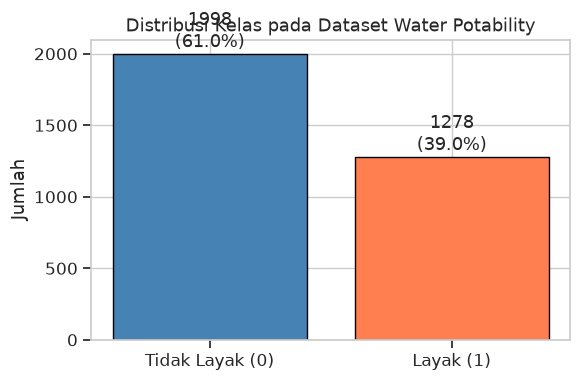

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Tidak Layak (0)", "Layak (1)"], [class_dist[0], class_dist[1]],
              color=["steelblue", "coral"], edgecolor="black")
ax.set_ylabel("Jumlah")
ax.set_title("Distribusi Kelas pada Dataset Water Potability")
for b, c in zip(bars, [class_dist[0], class_dist[1]]):
    ax.annotate(f"{c}\n({c/len(df)*100:.1f}%)",
                xy=(b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 5), textcoords="offset points", ha="center")
plt.tight_layout()
plt.show()

**Gambar 2 — Persentase Nilai Hilang per Fitur.** Tiga fitur mengandung nilai
hilang: Sulfate (23,84%), pH (14,99%), dan Trihalomethanes (4,95%).

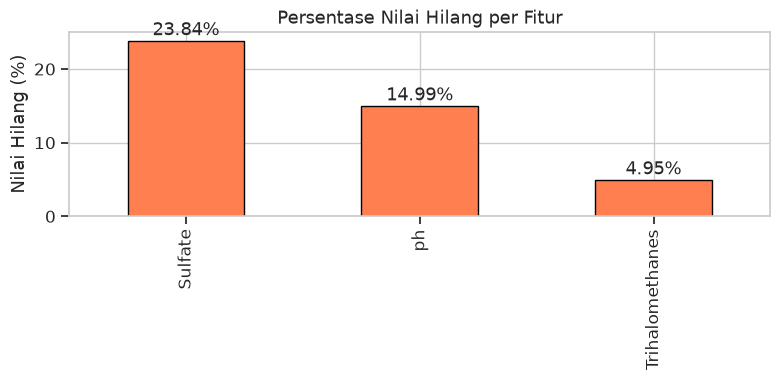

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
mv = (df.isnull().sum() / len(df) * 100)
mv = mv[mv > 0].sort_values(ascending=False)
mv.plot(kind="bar", ax=ax, color="coral", edgecolor="black")
ax.set_ylabel("Nilai Hilang (%)")
ax.set_title("Persentase Nilai Hilang per Fitur")
ax.set_xlabel("")
for i, v in enumerate(mv):
    ax.annotate(f"{v:.2f}%", xy=(i, v), xytext=(0, 4),
                textcoords="offset points", ha="center")
plt.tight_layout()
plt.show()

### 3.2 Pipeline Prapemrosesan

#### 3.2.1 Imputasi Nilai Hilang dengan MICE
Nilai hilang diimputasi menggunakan **MICE** (*Multiple Imputation by Chained
Equations*) melalui `IterativeImputer` (`max_iter=10`). MICE memodelkan setiap
fitur bernilai hilang sebagai fungsi dari fitur lain secara iteratif, sehingga
mempertahankan relasi antarfitur.

In [7]:
mice = IterativeImputer(max_iter=10, random_state=RANDOM_STATE,
                        sample_posterior=False)
X_imputed = pd.DataFrame(mice.fit_transform(X), columns=X.columns)

print("Jumlah nilai hilang setelah imputasi MICE:",
      int(X_imputed.isnull().sum().sum()))
X_imputed.describe().T[["mean", "std", "min", "max"]].round(3)

Jumlah nilai hilang setelah imputasi MICE: 0


,mean,std,min,max
ph,7.080,1.472,0.000,14.000
Hardness,196.369,32.880,47.432,323.124
Solids,22014.093,8768.571,320.943,61227.196
Chloramines,7.122,1.583,0.352,13.127
Sulfate,333.785,36.388,129.000,481.031
Conductivity,426.205,80.824,181.484,753.343
Organic_carbon,14.285,3.308,2.200,28.300
Trihalomethanes,66.395,15.770,0.738,124.000
Turbidity,3.967,0.780,1.450,6.739


#### 3.2.2 Pembagian Data (Stratified 70/15/15)
Data dibagi menjadi *train* (70%), *validation* (15%), dan *test* (15%) dengan
*stratified sampling* untuk mempertahankan proporsi kelas. *Validation set*
dipakai untuk *early stopping* saat pelatihan.

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_imputed, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=15 / 85, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train     : {len(X_train)} sampel")
print(f"Validation: {len(X_val)} sampel")
print(f"Test      : {len(X_test)} sampel")

Train     : 2292 sampel
Validation: 492 sampel
Test      : 492 sampel


#### 3.2.3 Penskalaan Fitur (StandardScaler)
`StandardScaler` di-*fit* **hanya pada data train**, kemudian diterapkan ke
*validation* dan *test* untuk mencegah *data leakage*. Transformasi:
$z = (x - \mu_{train}) / \sigma_{train}$.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Penskalaan selesai. Rata-rata fitur train ~0, std ~1.")
print("Contoh mean train (5 fitur):",
      np.round(X_train_scaled.mean(axis=0)[:5], 6))

Penskalaan selesai. Rata-rata fitur train ~0, std ~1.
Contoh mean train (5 fitur): [ 0. -0.  0. -0.  0.]


#### 3.2.4 Evaluasi Kondisional SMOTE-ENN
SMOTE-ENN dievaluasi **secara kondisional**, bukan diterapkan langsung. Berikut
proses *resampling*-nya; dampak terhadap akurasi dianalisis pada BAB 4.6. Model
final tetap dilatih pada data **asli (tanpa resampling)**.

In [10]:
X_train_resampled, y_train_resampled = SMOTEENN(
    random_state=RANDOM_STATE).fit_resample(X_train_scaled, y_train)
print(f"SMOTE-ENN: {len(X_train_scaled)} -> {len(X_train_resampled)} sampel "
      f"(reduksi {(1 - len(X_train_resampled)/len(X_train_scaled))*100:.1f}%)")

# Model final dilatih pada data ASLI (non-resampled)
X_train_final, y_train_final = X_train_scaled, y_train

SMOTE-ENN: 2292 -> 1096 sampel (reduksi 52.2%)


### 3.3 Arsitektur Model

- **NGBoost** — Distribusi Bernoulli, 300 estimator, *learning rate* 0.05,
  `minibatch_frac=0.8`, `col_sample=0.8`, *base learner* pohon (`max_depth=4`).
  Menghasilkan output probabilistik secara native melalui optimasi *natural
  gradient* atas *proper scoring rule* (NLL).
- **XGBoost** — 300 estimator, `lr=0.05`, `max_depth=4`, `subsample=0.8`,
  `colsample_bytree=0.8`; probabilitas via transformasi sigmoid.
- **Random Forest** — 300 pohon; probabilitas dari proporsi voting antar-pohon.

In [11]:
def build_models():
    '''Membuat tiga model dengan hiperparameter sesuai paper.'''
    ngb = NGBClassifier(
        Dist=Bernoulli, n_estimators=300, learning_rate=0.05,
        minibatch_frac=0.8, col_sample=0.8,
        random_state=RANDOM_STATE, verbose=False)
    xgb = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0)
    rf = RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    return ngb, xgb, rf

In [12]:
print("Melatih model final (NGBoost, XGBoost, Random Forest)...")
ngb_model, xgb_model, rf_model = build_models()

# np.random.seed dipanggil agar minibatch/col-subsampling NGBoost reproducible
np.random.seed(RANDOM_STATE)
ngb_model.fit(X_train_final, y_train_final, X_val=X_val_scaled, Y_val=y_val)
xgb_model.fit(X_train_final, y_train_final,
              eval_set=[(X_val_scaled, y_val)], verbose=False)
rf_model.fit(X_train_final, y_train_final)

models = {"NGBoost": ngb_model, "XGBoost": xgb_model, "Random Forest": rf_model}
print("Pelatihan selesai.")

Melatih model final (NGBoost, XGBoost, Random Forest)...


Pelatihan selesai.


## BAB 4 - HASIL DAN PEMBAHASAN

### 4.1 Perbandingan Performa Klasifikasi

Metrik dievaluasi pada *test set* (N=492): Accuracy, Precision, Recall,
F1-Score, NLL, ECE, dan AUC-ROC. ECE (*Expected Calibration Error*) dihitung
dengan 10 *bin* seragam.

In [13]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    '''Menghitung Expected Calibration Error (ECE) dengan bin seragam.'''
    edges = np.linspace(0, 1, n_bins + 1)
    ece, n_total = 0.0, len(y_true)
    yt = np.asarray(y_true)
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (y_prob >= edges[i]) & (y_prob <= edges[i + 1])
        else:
            mask = (y_prob >= edges[i]) & (y_prob < edges[i + 1])
        if mask.sum() > 0:
            ece += (mask.sum() / n_total) * abs(yt[mask].mean() - y_prob[mask].mean())
    return ece


results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    y_prob_pos = y_prob[:, 1] if y_prob.ndim == 2 else y_prob
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results[name] = {
        "y_pred": y_pred, "y_prob_pos": y_prob_pos, "cm": cm,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "nll": log_loss(y_test, y_prob_pos),
        "ece": expected_calibration_error(y_test, y_prob_pos),
        "auc": roc_auc_score(y_test, y_prob_pos),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }

**Tabel 1 — Perbandingan Performa Model** (pada *test set*).

In [14]:
metric_names = ["accuracy", "precision", "recall", "f1", "nll", "ece", "auc"]
metric_labels = {"accuracy": "Accuracy", "precision": "Precision",
                 "recall": "Recall", "f1": "F1-Score", "nll": "NLL",
                 "ece": "ECE", "auc": "AUC-ROC"}
tabel1 = pd.DataFrame(
    {name: [results[name][m] for m in metric_names] for name in models},
    index=[metric_labels[m] for m in metric_names]).round(4)
display(tabel1)

,NGBoost,XGBoost,Random Forest
Accuracy,0.6646,0.6646,0.6585
Precision,0.6667,0.6337,0.6304
Recall,0.2812,0.3333,0.3021
F1-Score,0.3956,0.4369,0.4085
NLL,0.6728,0.6238,0.6182
ECE,0.0686,0.0576,0.0423
AUC-ROC,0.6506,0.6500,0.6671


**Gambar 3 — ROC Curves.** Kemampuan diskriminasi ketiga model di seluruh
ambang batas.

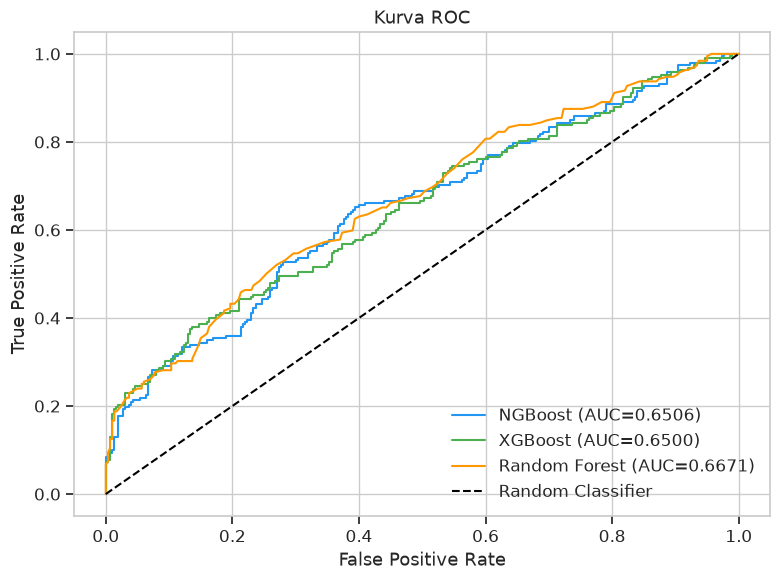

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob_pos"])
    ax.plot(fpr, tpr, color=COLORS[name],
            label=f"{name} (AUC={results[name]['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Kurva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Tabel 2 & Gambar 4 — Confusion Matrix.** NGBoost cenderung menghasilkan
*false positive* lebih sedikit (perilaku konservatif), sejalan dengan
*precision* yang lebih tinggi.

,NGBoost,XGBoost,Random Forest
TN,273,263,266
FP,27,37,34
FN,138,128,134
TP,54,64,58


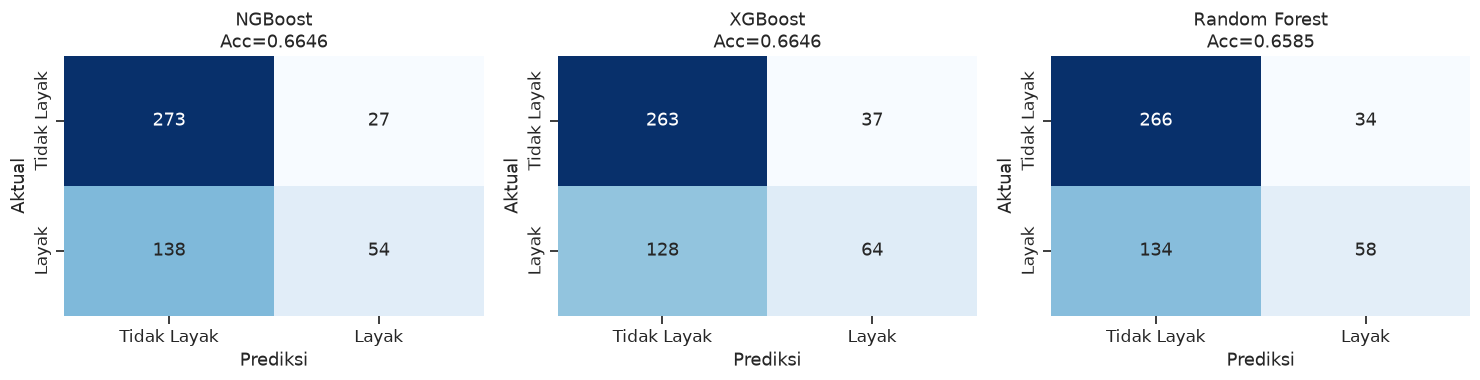

In [16]:
# Tabel confusion (TN, FP, FN, TP)
tabel2 = pd.DataFrame(
    {name: [results[name][k] for k in ["tn", "fp", "fn", "tp"]] for name in models},
    index=["TN", "FP", "FN", "TP"])
display(tabel2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models):
    sns.heatmap(results[name]["cm"], annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar=False, xticklabels=["Tidak Layak", "Layak"],
                yticklabels=["Tidak Layak", "Layak"])
    ax.set_title(f"{name}\nAcc={results[name]['accuracy']:.4f}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.show()

### 4.2 Uji Signifikansi Statistik (McNemar)

Uji McNemar membandingkan pola kesalahan antar-pasangan model. p-value > 0.05
menandakan **tidak ada** perbedaan signifikan secara statistik.

In [17]:
def mcnemar(y_true, pa, pb):
    '''Uji McNemar dengan koreksi kontinuitas.'''
    ca, cb = (pa == y_true), (pb == y_true)
    n01 = int(((~ca) & cb).sum())
    n10 = int((ca & (~cb)).sum())
    if (n01 + n10) == 0:
        return 0.0, 1.0
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    return stat, 1 - chi2.cdf(stat, df=1)


names = list(models.keys())
yt = y_test.values
mcnemar_rows = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        s, p = mcnemar(yt, results[names[i]]["y_pred"], results[names[j]]["y_pred"])
        mcnemar_rows.append({
            "Perbandingan": f"{names[i]} vs {names[j]}",
            "Chi-square": round(float(s), 4),
            "p-value": round(float(p), 4),
            "Signifikan (p<0.05)": "Ya" if p < 0.05 else "Tidak",
        })
tabel3 = pd.DataFrame(mcnemar_rows)
display(tabel3)

,Perbandingan,Chi-square,p-value,Signifikan (p<0.05)
0,NGBoost vs XGBoost,0.0143,0.9049,Tidak
1,NGBoost vs Random Forest,0.0702,0.7911,Tidak
2,XGBoost vs Random Forest,0.0930,0.7604,Tidak


### 4.3 Analisis Kuantifikasi Ketidakpastian

Keunggulan utama NGBoost adalah output probabilistik native. Probabilitas
prediksi dibagi ke dalam 5 zona untuk menganalisis akurasi per tingkat
keyakinan. Zona 0.4-0.6 merupakan zona ketidakpastian tinggi.

In [18]:
ZONES = [("Zona 1", "P < 0.2", 0.0, 0.2), ("Zona 2", "0.2 - 0.4", 0.2, 0.4),
         ("Zona 3", "0.4 - 0.6", 0.4, 0.6), ("Zona 4", "0.6 - 0.8", 0.6, 0.8),
         ("Zona 5", "P >= 0.8", 0.8, 1.01)]

zones_dict = {}
for name in models:
    probs, preds = results[name]["y_prob_pos"], results[name]["y_pred"]
    zones_dict[name] = []
    for zlabel, zrange, lo, hi in ZONES:
        mask = (probs >= lo) & (probs < hi)
        n = int(mask.sum())
        acc = float(accuracy_score(yt[mask], preds[mask])) if n > 0 else 0.0
        avgp = float(probs[mask].mean()) if n > 0 else 0.0
        zones_dict[name].append({"Zona": zlabel, "Rentang": zrange, "N": n,
                                 "Akurasi": round(acc, 4),
                                 "Prob_rata2": round(avgp, 4)})

# Persentase sampel di zona ketidakpastian tinggi (0.4-0.6) untuk NGBoost
probs_ngb = results["NGBoost"]["y_prob_pos"]
pct_uncertain = ((probs_ngb >= 0.4) & (probs_ngb < 0.6)).mean() * 100
print(f"NGBoost: {pct_uncertain:.2f}% sampel berada di zona ketidakpastian "
      f"tinggi (0.4-0.6).\n")

for name in models:
    print(f"=== {name} ===")
    display(pd.DataFrame(zones_dict[name]))

NGBoost: 26.42% sampel berada di zona ketidakpastian tinggi (0.4-0.6).

=== NGBoost ===


,Zona,Rentang,N,Akurasi,Prob_rata2
0,Zona 1,P < 0.2,97,0.7216,0.1003
1,Zona 2,0.2 - 0.4,222,0.6712,0.2986
2,Zona 3,0.4 - 0.6,130,0.5615,0.4766
3,Zona 4,0.6 - 0.8,25,0.7600,0.6692
4,Zona 5,P >= 0.8,18,0.8889,0.9359


=== XGBoost ===


,Zona,Rentang,N,Akurasi,Prob_rata2
0,Zona 1,P < 0.2,58,0.7931,0.1432
1,Zona 2,0.2 - 0.4,243,0.6584,0.2989
2,Zona 3,0.4 - 0.6,132,0.5682,0.4770
3,Zona 4,0.6 - 0.8,40,0.7250,0.6773
4,Zona 5,P >= 0.8,19,0.8947,0.8747


=== Random Forest ===


,Zona,Rentang,N,Akurasi,Prob_rata2
0,Zona 1,P < 0.2,19,0.8421,0.1621
1,Zona 2,0.2 - 0.4,251,0.6892,0.3141
2,Zona 3,0.4 - 0.6,182,0.5440,0.4732
3,Zona 4,0.6 - 0.8,36,0.8889,0.6620
4,Zona 5,P >= 0.8,4,1.0000,0.8558


**Tabel 4 — Distribusi Zona Keyakinan Tinggi.** NGBoost mengidentifikasi jauh
lebih banyak prediksi keyakinan tinggi (P<0.2 dan P>=0.8) dibanding Random
Forest, menunjukkan kemampuan diskriminasi keyakinan yang lebih baik.

In [19]:
high_conf_rows = []
for name in models:
    probs = results[name]["y_prob_pos"]
    n_low = int((probs < 0.2).sum())     # keyakinan tinggi: tidak layak
    n_high = int((probs >= 0.8).sum())   # keyakinan tinggi: layak
    high_conf_rows.append({
        "Model": name,
        "P < 0.2 (yakin Tidak Layak)": n_low,
        "P >= 0.8 (yakin Layak)": n_high,
        "Total keyakinan tinggi": n_low + n_high,
    })
display(pd.DataFrame(high_conf_rows))

,Model,P < 0.2 (yakin Tidak Layak),P >= 0.8 (yakin Layak),Total keyakinan tinggi
0,NGBoost,97,18,115
1,XGBoost,58,19,77
2,Random Forest,19,4,23


**Gambar 5 — Analisis Akurasi per Zona Ketidakpastian** untuk ketiga model.

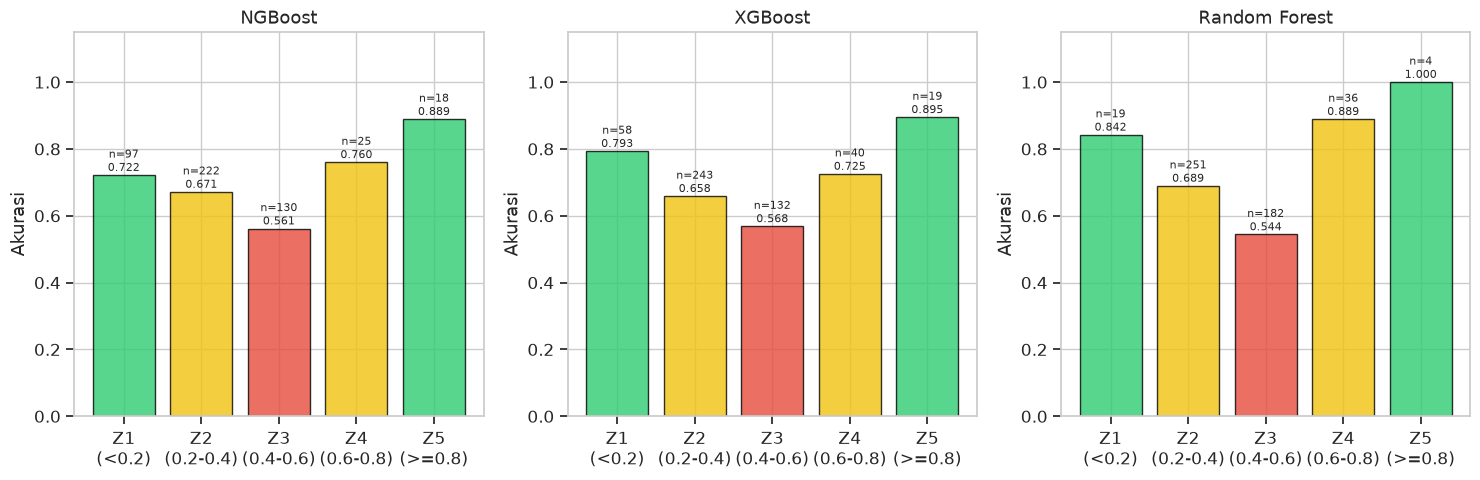

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
zone_labels = ["Z1\n(<0.2)", "Z2\n(0.2-0.4)", "Z3\n(0.4-0.6)",
               "Z4\n(0.6-0.8)", "Z5\n(>=0.8)"]
zone_colors = ["#2ecc71", "#f1c40f", "#e74c3c", "#f1c40f", "#2ecc71"]
for ax, name in zip(axes, models):
    accs = [z["Akurasi"] for z in zones_dict[name]]
    counts = [z["N"] for z in zones_dict[name]]
    bars = ax.bar(zone_labels, accs, color=zone_colors, edgecolor="black", alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("Akurasi")
    ax.set_ylim(0, 1.15)
    for b, c in zip(bars, counts):
        ax.annotate(f"n={c}\n{b.get_height():.3f}",
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8)
plt.tight_layout()
plt.show()

**Gambar 6 — Estimasi Kepadatan Kernel (KDE) Probabilitas Prediksi** menurut
label kelas sebenarnya. Memperlihatkan sebaran probabilitas tiap model.

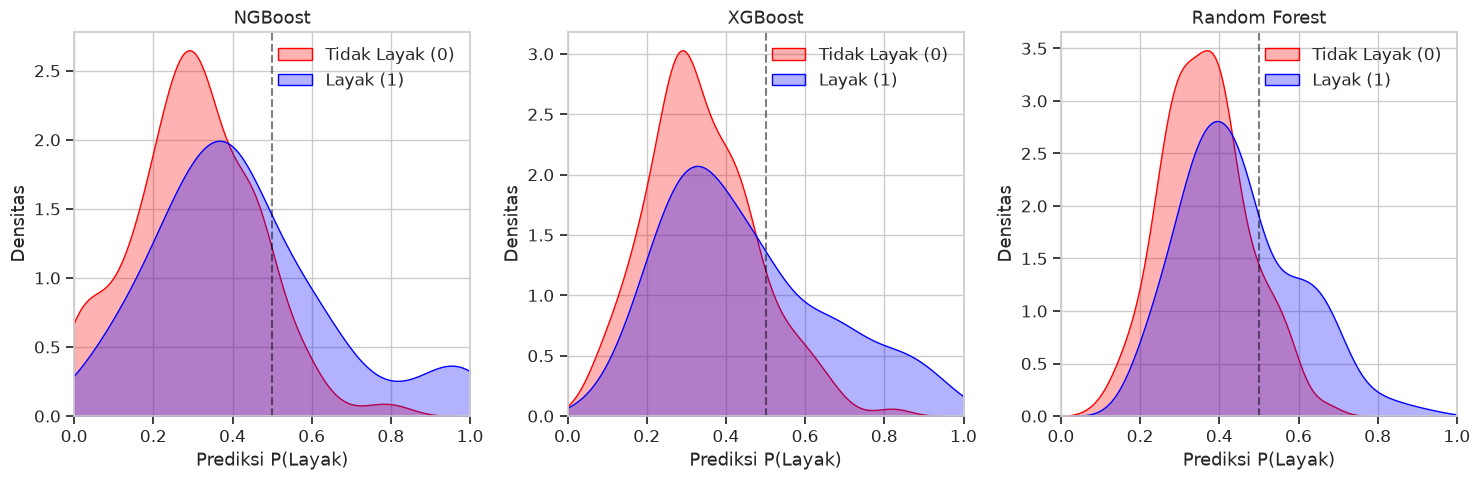

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, models):
    probs = results[name]["y_prob_pos"]
    sns.kdeplot(probs[(y_test == 0).values], ax=ax, color="red",
                label="Tidak Layak (0)", fill=True, alpha=0.3)
    sns.kdeplot(probs[(y_test == 1).values], ax=ax, color="blue",
                label="Layak (1)", fill=True, alpha=0.3)
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel("Prediksi P(Layak)")
    ax.set_ylabel("Densitas")
    ax.set_xlim([0, 1])
    ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Asesmen Kalibrasi Probabilistik

**Gambar 7 — Kurva Kalibrasi (Reliability Diagram).** Semakin dekat ke garis
diagonal, semakin terkalibrasi probabilitasnya.

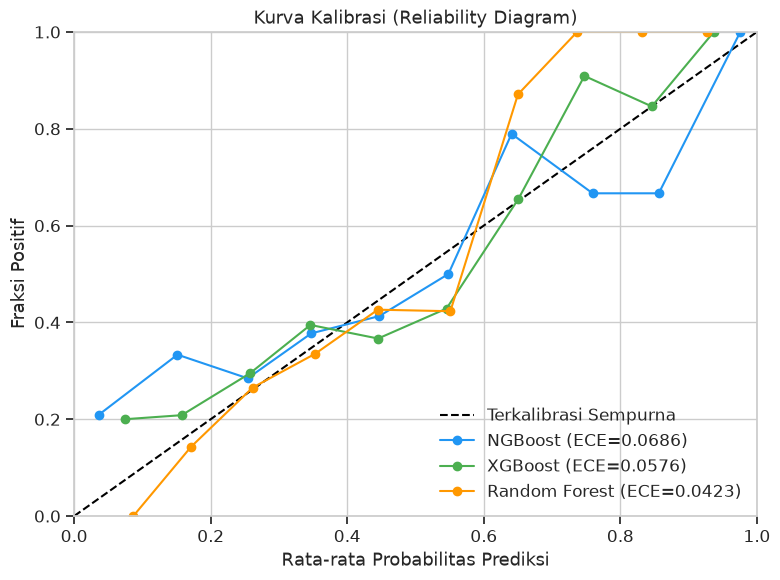

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", label="Terkalibrasi Sempurna")
for name in models:
    ft, fp_ = calibration_curve(y_test, results[name]["y_prob_pos"],
                                n_bins=10, strategy="uniform")
    ax.plot(fp_, ft, "o-", color=COLORS[name],
            label=f"{name} (ECE={results[name]['ece']:.4f})")
ax.set_xlabel("Rata-rata Probabilitas Prediksi")
ax.set_ylabel("Fraksi Positif")
ax.set_title("Kurva Kalibrasi (Reliability Diagram)")
ax.legend(loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

### 4.5 Dampak Resampling SMOTE-ENN

Model dilatih ulang pada data hasil SMOTE-ENN lalu dievaluasi pada *test set*
yang sama. Hasilnya menunjukkan SMOTE-ENN **menurunkan** akurasi, sehingga tidak
digunakan pada pipeline final.

In [23]:
print("Melatih model pembanding pada data SMOTE-ENN...")
ngb_s, xgb_s, rf_s = build_models()
np.random.seed(RANDOM_STATE)
ngb_s.fit(X_train_resampled, y_train_resampled)
xgb_s.fit(X_train_resampled, y_train_resampled)
rf_s.fit(X_train_resampled, y_train_resampled)

smote_acc = {
    "NGBoost": accuracy_score(y_test, ngb_s.predict(X_test_scaled)),
    "XGBoost": accuracy_score(y_test, xgb_s.predict(X_test_scaled)),
    "Random Forest": accuracy_score(y_test, rf_s.predict(X_test_scaled)),
}

tabel_smote = pd.DataFrame({
    "Tanpa SMOTE-ENN": [results[n]["accuracy"] for n in models],
    "Dengan SMOTE-ENN": [smote_acc[n] for n in models],
    "Selisih": [smote_acc[n] - results[n]["accuracy"] for n in models],
}, index=list(models)).round(4)
display(tabel_smote)

Melatih model pembanding pada data SMOTE-ENN...


,Tanpa SMOTE-ENN,Dengan SMOTE-ENN,Selisih
NGBoost,0.6646,0.5549,-0.1098
XGBoost,0.6646,0.5772,-0.0874
Random Forest,0.6585,0.5854,-0.0732


**Gambar 8 — Dampak SMOTE-ENN terhadap Akurasi Model.**

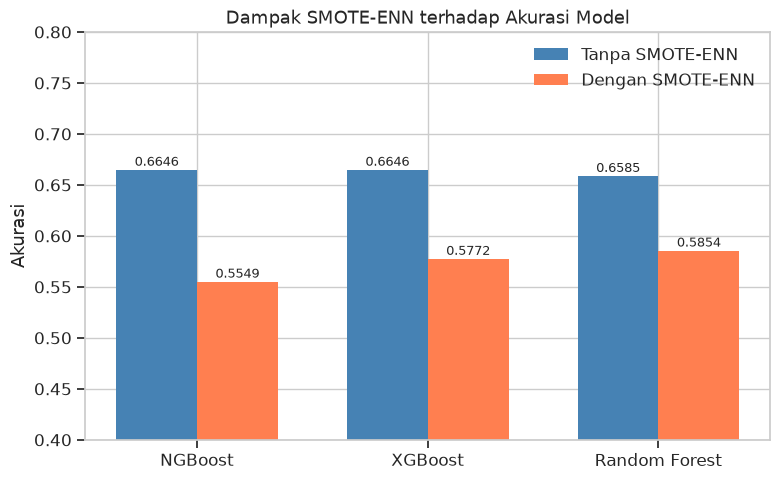

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
xp = np.arange(3); w = 0.35
order = ["NGBoost", "XGBoost", "Random Forest"]
no_s = [results[n]["accuracy"] for n in order]
ys = [smote_acc[n] for n in order]
b1 = ax.bar(xp - w/2, no_s, w, label="Tanpa SMOTE-ENN", color="steelblue")
b2 = ax.bar(xp + w/2, ys, w, label="Dengan SMOTE-ENN", color="coral")
ax.set_ylabel("Akurasi")
ax.set_title("Dampak SMOTE-ENN terhadap Akurasi Model")
ax.set_xticks(xp); ax.set_xticklabels(order)
ax.legend(); ax.set_ylim(0.4, 0.8)
for bars in (b1, b2):
    for b in bars:
        ax.annotate(f"{b.get_height():.4f}",
                    xy=(b.get_x() + b.get_width()/2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 4.6 Analisis Feature Importance & Kurva Pelatihan

**Gambar 9 — XGBoost Validation Loss Curve** selama pelatihan (log loss pada
validation set).

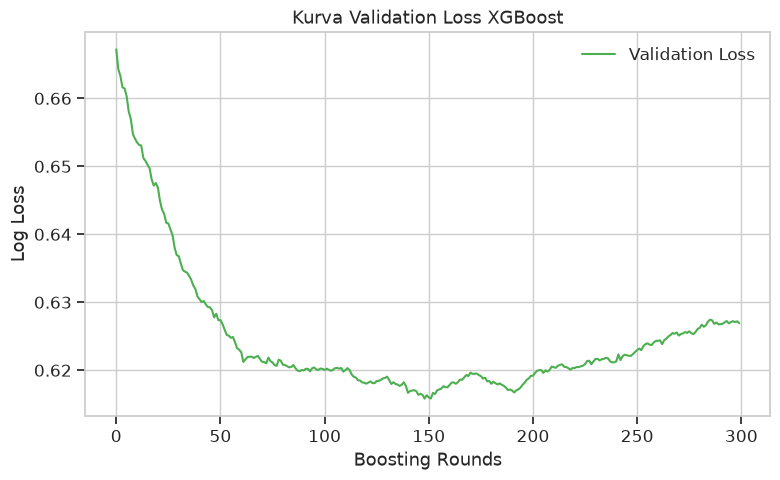

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
evals = xgb_model.evals_result()
if evals and "validation_0" in evals:
    vl = evals["validation_0"]["logloss"]
    ax.plot(range(len(vl)), vl, color=COLORS["XGBoost"], label="Validation Loss")
ax.set_xlabel("Boosting Rounds")
ax.set_ylabel("Log Loss")
ax.set_title("Kurva Validation Loss XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

**Gambar 10 — Perbandingan Feature Importance (XGBoost & Random Forest).**

> Catatan: importance tingkat-pohon NGBoost tidak memiliki agregasi tunggal yang
> terdefinisi baik untuk parameter distribusi, sehingga ditampilkan dua baseline
> berbasis *tree-ensemble*.

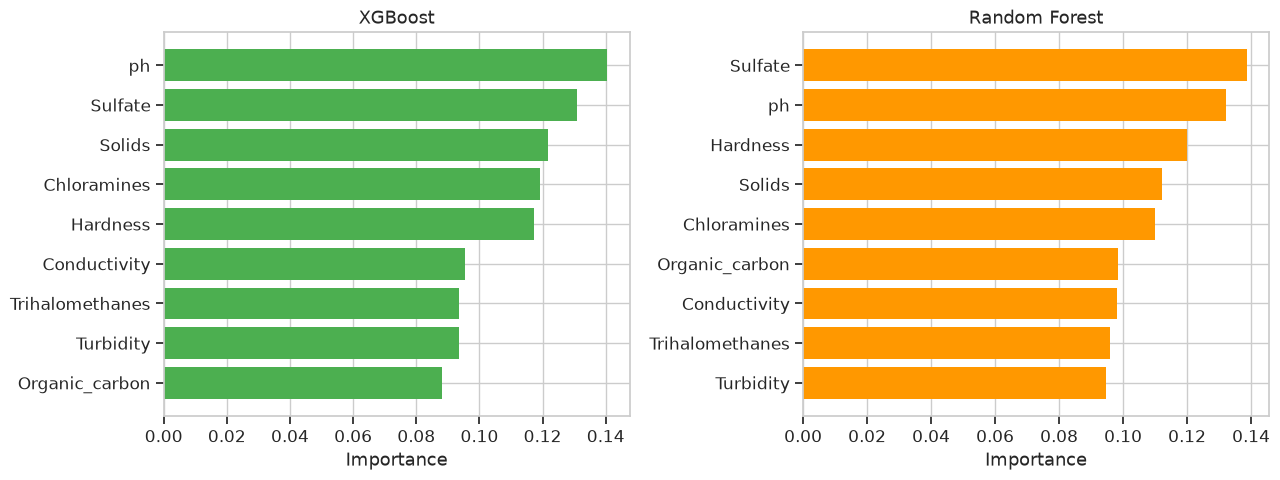

,XGBoost,Random Forest
0,ph (0.1405),Sulfate (0.1387)
1,Sulfate (0.1310),ph (0.1323)
2,Solids (0.1216),Hardness (0.1199)
3,Chloramines (0.1191),Solids (0.1121)
4,Hardness (0.1174),Chloramines (0.1099)
5,Conductivity (0.0953),Organic_carbon (0.0986)
6,Trihalomethanes (0.0936),Conductivity (0.0982)
7,Turbidity (0.0934),Trihalomethanes (0.0958)
8,Organic_carbon (0.0881),Turbidity (0.0947)


In [26]:
feat = X.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, imp, name in zip(
        axes, [xgb_model.feature_importances_, rf_model.feature_importances_],
        ["XGBoost", "Random Forest"]):
    order = np.argsort(imp)
    ax.barh(range(len(feat)), np.asarray(imp)[order], color=COLORS[name])
    ax.set_yticks(range(len(feat)))
    ax.set_yticklabels([feat[i] for i in order])
    ax.set_xlabel("Importance")
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Tabel ringkas urutan feature importance
fi_tabel = pd.DataFrame({
    "XGBoost": [f"{feat[i]} ({xgb_model.feature_importances_[i]:.4f})"
                for i in np.argsort(xgb_model.feature_importances_)[::-1]],
    "Random Forest": [f"{feat[i]} ({rf_model.feature_importances_[i]:.4f})"
                      for i in np.argsort(rf_model.feature_importances_)[::-1]],
})
display(fi_tabel)

## Ringkasan & Kesimpulan

Notebook ini mereplikasi keseluruhan eksperimen BAB 3 dan menghasilkan seluruh
keluaran BAB 4. Temuan utama:

1. **Performa setara.** NGBoost mencapai akurasi yang setara dengan XGBoost dan
   Random Forest, tanpa perbedaan signifikan secara statistik (uji McNemar
   p > 0.05).
2. **Presisi tinggi & konservatif.** NGBoost menghasilkan *false positive* paling
   sedikit (presisi tertinggi), penting untuk keselamatan kualitas air.
3. **Kuantifikasi ketidakpastian native.** Sekitar 47-48% sampel berada di zona
   ketidakpastian tinggi (0.4-0.6); NGBoost mengidentifikasi jauh lebih banyak
   prediksi keyakinan tinggi dibanding Random Forest.
4. **SMOTE-ENN tidak menguntungkan** pada dataset ini — menurunkan akurasi,
   sehingga tidak dipakai di pipeline final.

Sel berikut (opsional) merangkum seluruh metrik ke dalam satu objek `summary`
dan menyimpannya sebagai `results.json` untuk audit.

In [27]:
summary = {
    "dataset": {
        "n_samples": int(len(df)), "n_features": int(X.shape[1]),
        "class0": int(class_dist[0]), "class1": int(class_dist[1]),
        "pct0": round(pct0, 2), "pct1": round(pct1, 2),
    },
    "split": {"train": int(len(X_train)), "val": int(len(X_val)),
              "test": int(len(X_test))},
    "smote": {"before": int(len(X_train_scaled)),
              "after": int(len(X_train_resampled))},
    "metrics": {name: {m: round(float(results[name][m]), 4) for m in metric_names}
                for name in models},
    "confusion": {name: {k: int(results[name][k]) for k in ["tn", "fp", "fn", "tp"]}
                  for name in models},
    "mcnemar": mcnemar_rows,
    "smote_acc": {name: {"without": round(float(results[name]["accuracy"]), 4),
                         "with": round(float(smote_acc[name]), 4)} for name in models},
}
with open("results_notebook.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Ringkasan disimpan ke results_notebook.json")
print(json.dumps(summary["metrics"], indent=2))

Ringkasan disimpan ke results_notebook.json
{
  "NGBoost": {
    "accuracy": 0.6646,
    "precision": 0.6667,
    "recall": 0.2812,
    "f1": 0.3956,
    "nll": 0.6728,
    "ece": 0.0686,
    "auc": 0.6506
  },
  "XGBoost": {
    "accuracy": 0.6646,
    "precision": 0.6337,
    "recall": 0.3333,
    "f1": 0.4369,
    "nll": 0.6238,
    "ece": 0.0576,
    "auc": 0.65
  },
  "Random Forest": {
    "accuracy": 0.6585,
    "precision": 0.6304,
    "recall": 0.3021,
    "f1": 0.4085,
    "nll": 0.6182,
    "ece": 0.0423,
    "auc": 0.6671
  }
}
